In [1]:
import os
import xarray as xr
from src import loader, zdF, roi, timesync, visualizations
import glob
from nre.io import load
import numpy as np
import pandas as pd
from tqdm import tqdm
import h5py
import nibabel as nib
import matplotlib.pyplot as plt
from flymetrics.utils import fill_missing

In [14]:
base_data_path = '/Volumes/AhmedLab/princess/data/pIP10'
experiment_id = 'pIP10_TSeries_20260427_GC8m_fly09_win02_trial-001'
processed_path = loader.get_base_path(experiment_id=experiment_id, data_stage='processed', base_dir=base_data_path)
import glob
# from scipy.signal import savgol_filter
# from src import correlations
# dat_file = glob.glob(f'{processed_path}/*.dat')[0]
# fictrac_data = pd.DataFrame(pd.read_csv(dat_file, header=None))
# camera_framerate = 170
# win_size = int(.5 * camera_framerate)
# inst_speed = np.rad2deg(fictrac_data[18])

In [15]:
cluster_labels, signal, voltage_timestamps = loader.load_clusters(processed_path)

In [16]:
def pull_fictrac_speed(dat_file, camera_framerate = 170, smoothing_window_s = 0.5):
    dat_dataframe = pd.DataFrame(pd.read_csv(dat_file, header=None))
    inst_speed = np.rad2deg(dat_dataframe[18])

    window_size = int(smoothing_window_s * camera_framerate)

# win_size = int(.25 * camera_framerate)
# speed_smoothed = savgol_filter(inst_speed, win_size, 3)


In [17]:
signal_xr = xr.DataArray(
    data=signal,
    dims=['zposs', 'roi', 'time'],
    coords={'time': range(signal.shape[2])}
)
dimensions = [512, 512, 11]


In [18]:
def convert_frametimestamps_to_datetime(timestamps_dataframe):
    # this selects the first slice fo teh volume to use as our timestamp
    t0 = np.datetime64('2025-01-01T00:00:00')
    volume_deltas = np.round(timestamps_dataframe[::11]).astype('<m8[ms]')
    dt_timestamps = t0 + volume_deltas
    return dt_timestamps

timestamps = convert_frametimestamps_to_datetime(voltage_timestamps)
print(timestamps)

[['2025-01-01T00:00:00.067']
 ['2025-01-01T00:00:00.498']
 ['2025-01-01T00:00:00.930']
 ...
 ['2025-01-01T00:19:58.838']
 ['2025-01-01T00:19:59.270']
 ['2025-01-01T00:19:59.702']]


2779 156791
2779 2779


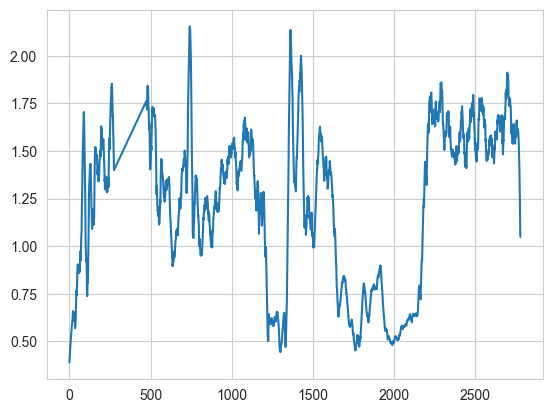

In [19]:
slow_signal = np.array(signal_xr.coords['time'])
fast_signal = np.array(inst_speed)
print(len(slow_signal), len(fast_signal))

slow = slow_signal
fast = fast_signal

max_divider = fast.shape[0] // slow.shape[0]
fast_cut = fast[:slow.shape[0] * max_divider]  # cut excess behavior data
fast_reshaped = np.reshape(fast_cut, (slow.shape[0], -1))
fast_downsample = np.mean(fast_reshaped, axis=1)
print(fast_downsample.shape[0], slow.shape[0])

behavior_downsampled = fast_downsample
# plt.plot(behavior_downsampled)
# for ind, val in enumerate(behavior_downsampled):
#     if behavior_downsampled[ind] < 3:
#         behavior_downsampled[ind] = np.nan()
# behavior_downsampled = savgol_filter(behavior_downsampled, win_size, 3)

behavior_downsampled[behavior_downsampled > 5] = np.nan
behavior_downsampled = savgol_filter(behavior_downsampled, win_size, 3)
behavior_downsampled = fill_missing(behavior_downsampled)
plt.plot(behavior_downsampled)

In [20]:
clusters_toplot = [ [7,10], [7,8], [8,19], [8,6], [9,19], [10,11]]

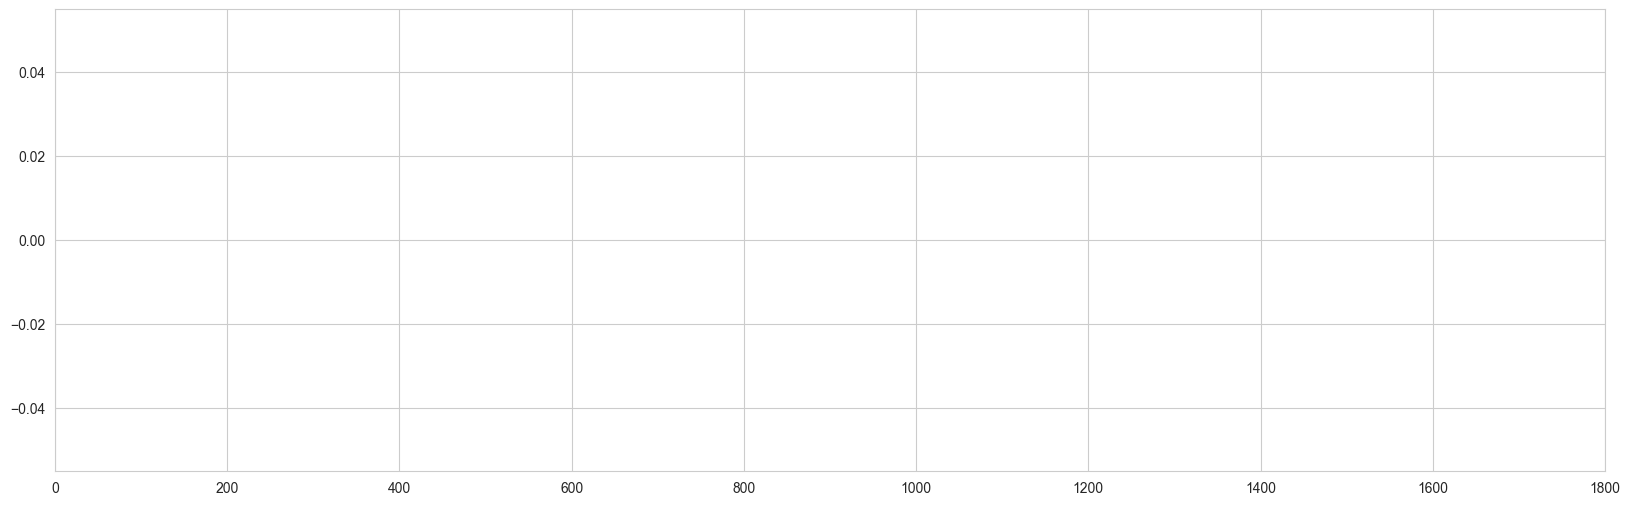

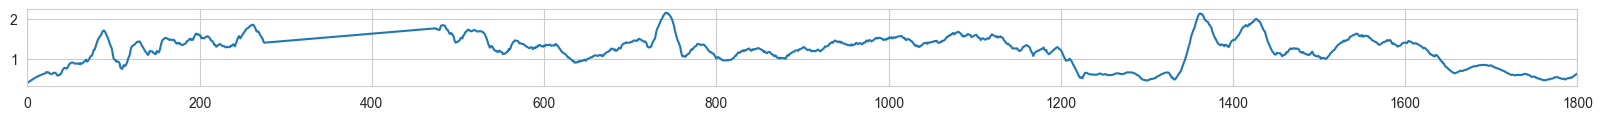

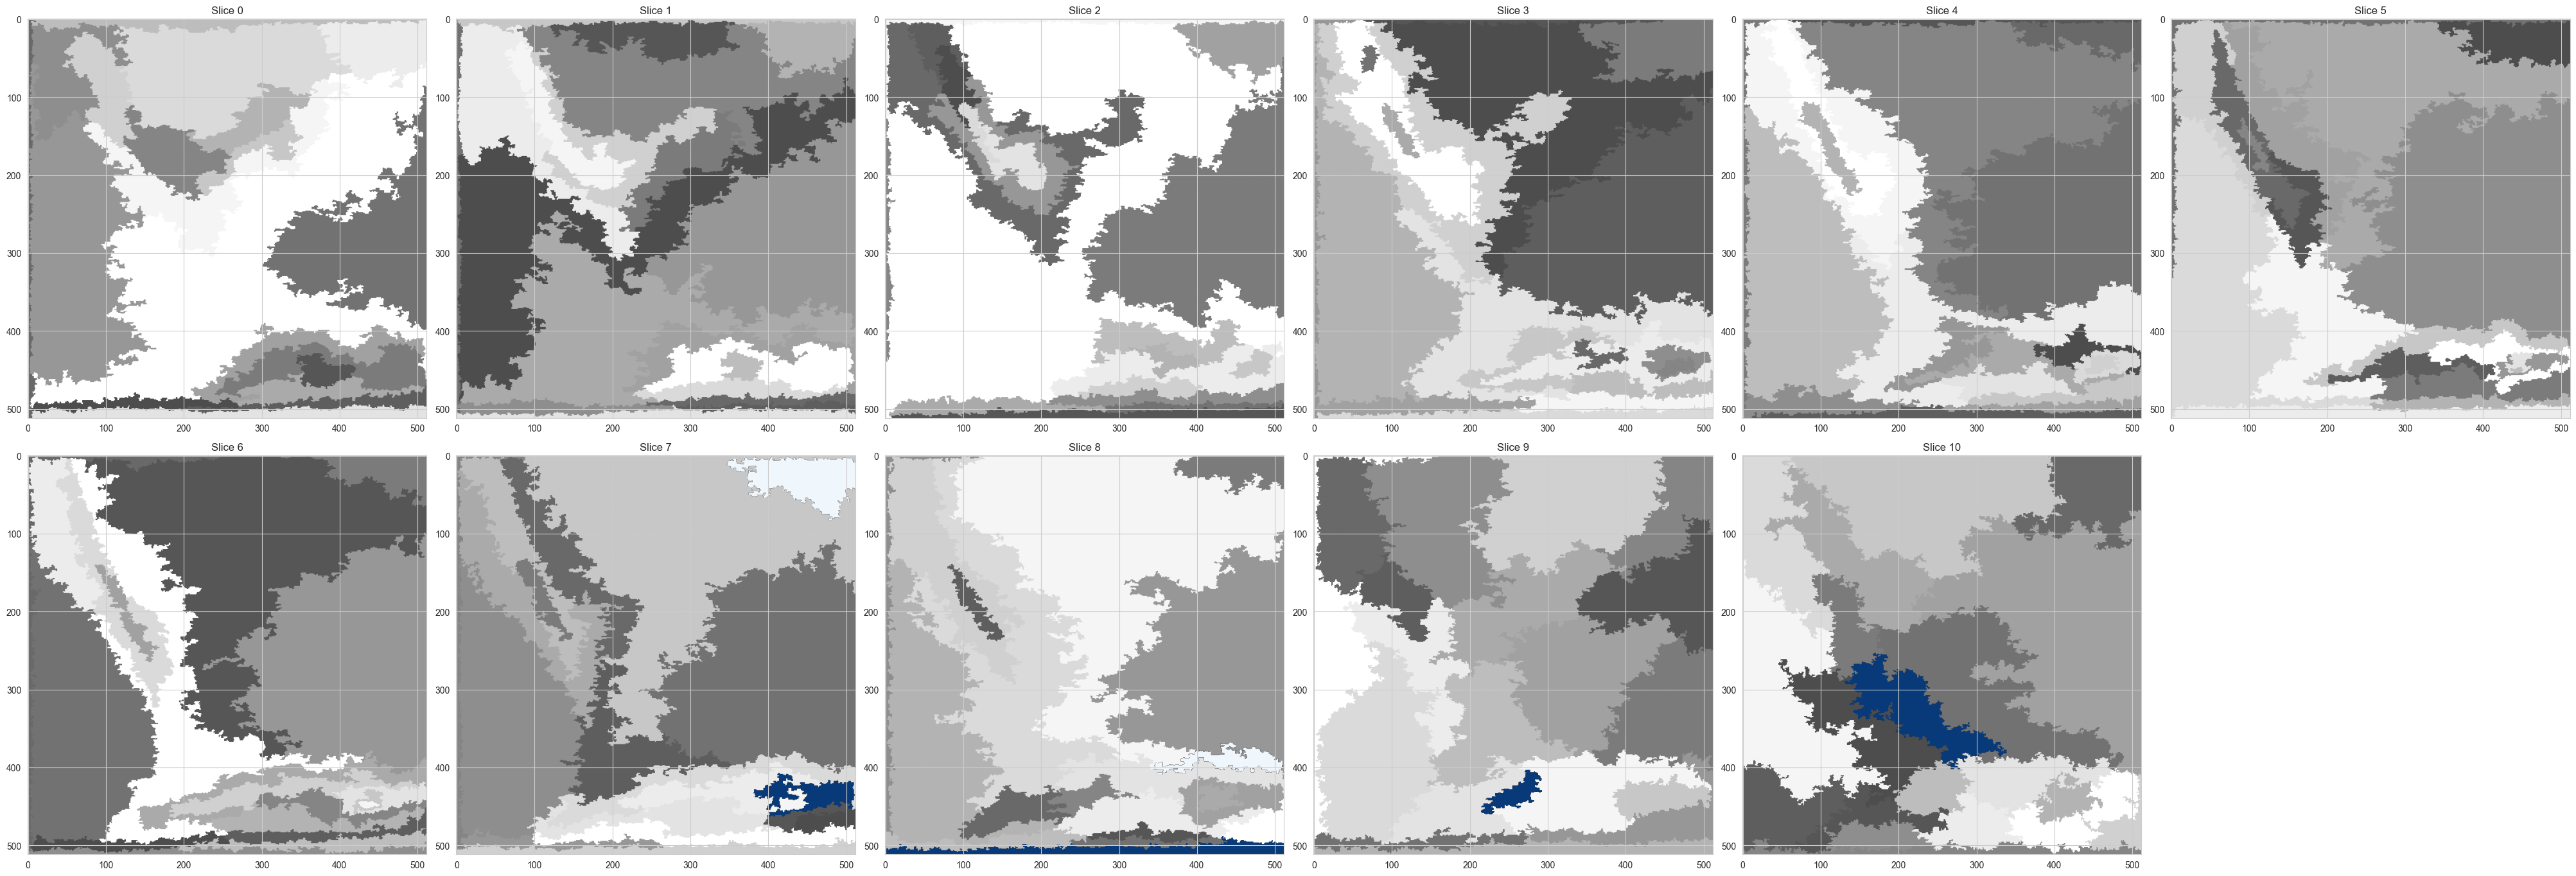

In [21]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(20,len(clusters_toplot)))
yshift = 5
palette_colors = sns.color_palette('Blues_r', 25)
for idx, ind_cluster in enumerate(clusters_toplot):
    to_plot = signal_xr.isel(zposs=ind_cluster[0], roi=ind_cluster[1])
    ax.plot(signal_xr.coords['time'],to_plot + (yshift*idx), color=palette_colors[idx])
    plt.xlim(0,1800)
fig, ax = plt.subplots(figsize=(20,1))
ax.plot(behavior_downsampled)
plt.xlim(0,1800)
# fig, ax = plt.subplots(figsize=(20,len(clusters_toplot)))
visualizations.plot_spatial_location(clusters_toplot, cluster_labels, dimensions)